In [1]:
import os
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
TRAIN_JSON = r"C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving\data\processed_json\train.json"
VAL_JSON   = r"C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving\data\processed_json\val.json"
TEST_JSON  = r"C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving\data\processed_json\test.json"

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

df_train = pd.DataFrame(train)
df_val   = pd.DataFrame(val)
df_test  = pd.DataFrame(test)

# Basic sanity check

print("Train shape:", df_train.shape)
print("Val shape:  ", df_val.shape)
print("Test shape: ", df_test.shape)

df_train.head()

Train shape: (6509, 15)
Val shape:   (1499, 15)
Test shape:  (1501, 15)


,image_front_right,image_front,image_front_left,seg_front,boxes,box_labels,velocity_x,velocity_y,velocity_z,speed_kmh,throttle,steer,brake,nearest_object_dist,box_count
0,data/hf_data\images\988_front_right.png,data/hf_data\images\988_front.png,data/hf_data\images\988_left.png,data/hf_data\images\988_seg_front.png,"[[237.560546875, 304.4198303222656, 250.088806...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",0.000000,0.000000,0.000000,0.000000,0.000000,-0.167606,1.0,83.772867,13
1,data/hf_data\images\4626_front_right.png,data/hf_data\images\4626_front.png,data/hf_data\images\4626_left.png,data/hf_data\images\4626_seg_front.png,"[[0.0, 161.9890594482422, 290.5579833984375, 4...","[vehicle, vehicle, vehicle, vehicle, vehicle]",0.000000,0.000000,0.000000,0.000000,0.000000,-0.070127,1.0,89.834725,5
2,data/hf_data\images\7134_front_right.png,data/hf_data\images\7134_front.png,data/hf_data\images\7134_left.png,data/hf_data\images\7134_seg_front.png,"[[249.60365295410156, 305.7678527832031, 264.6...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",0.000032,0.001235,0.008557,0.031124,0.000000,-0.212528,1.0,81.847457,16
3,data/hf_data\images\1243_front_right.png,data/hf_data\images\1243_front.png,data/hf_data\images\1243_left.png,data/hf_data\images\1243_seg_front.png,"[[260.46002197265625, 322.02911376953125, 336....",[vehicle],-6.631937,3.240572,-0.004740,26.572762,0.054285,-0.271541,0.0,226.057457,1
4,data/hf_data\images\6487_front_right.png,data/hf_data\images\6487_front.png,data/hf_data\images\6487_left.png,data/hf_data\images\6487_seg_front.png,"[[342.3039245605469, 296.5711669921875, 378.45...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",8.243203,0.070718,0.076786,29.677912,0.127754,0.025580,0.0,83.017329,7


In [9]:
# Feature types 

df_train.dtypes

image_front_right       object
image_front             object
image_front_left        object
seg_front               object
boxes                   object
box_labels              object
velocity_x             float64
velocity_y             float64
velocity_z             float64
speed_kmh              float64
throttle               float64
steer                  float64
brake                  float64
nearest_object_dist    float64
box_count                int64
dtype: object

In [11]:
# missing values

df_train.isna().sum().sort_values(ascending=False)

image_front_right      0
image_front            0
image_front_left       0
seg_front              0
boxes                  0
box_labels             0
velocity_x             0
velocity_y             0
velocity_z             0
speed_kmh              0
throttle               0
steer                  0
brake                  0
nearest_object_dist    0
box_count              0
dtype: int64

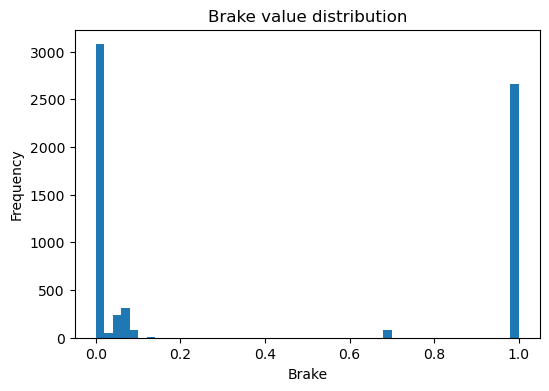

 Percentage of sample involve braking : 52.81917345214319


In [13]:
# Brake distribution

df_train["brake"].describe()

plt.figure(figsize=(6,4))
plt.hist(df_train["brake"], bins=50)
plt.title("Brake value distribution")
plt.xlabel("Brake")
plt.ylabel("Frequency")
plt.show()

# % of samples involve braking

print(" Percentage of sample involve braking :", (df_train["brake"] > 0).mean() * 100) 


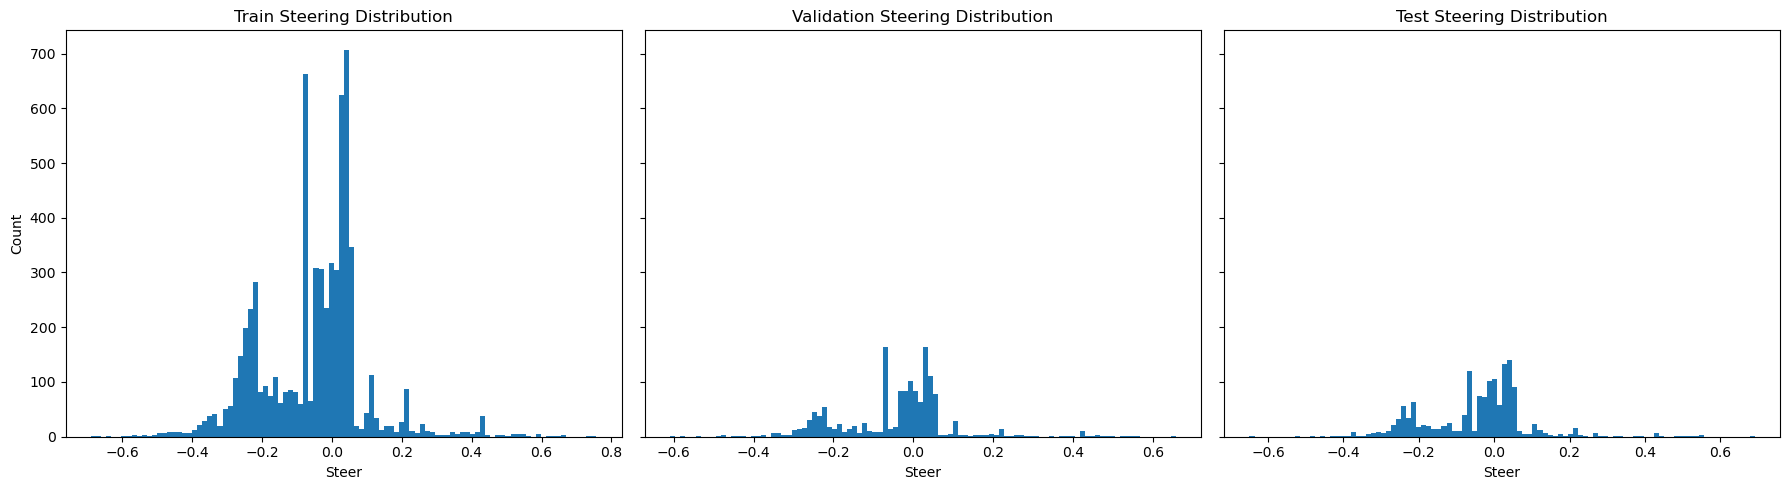

In [15]:
# Train Steering Angle Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

bins = 100

axes[0].hist(df_train["steer"], bins=bins)
axes[0].set_title("Train Steering Distribution")
axes[0].set_xlabel("Steer")
axes[0].set_ylabel("Count")

axes[1].hist(df_val["steer"], bins=bins)
axes[1].set_title("Validation Steering Distribution")
axes[1].set_xlabel("Steer")

axes[2].hist(df_test["steer"], bins=bins)
axes[2].set_title("Test Steering Distribution")
axes[2].set_xlabel("Steer")

plt.tight_layout()
plt.show()

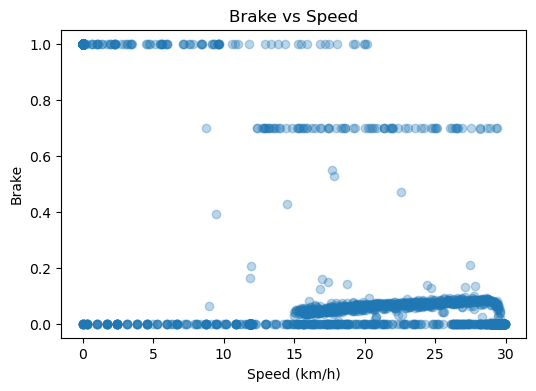

In [17]:
# Brake vs speed

plt.figure(figsize=(6,4))
plt.scatter(df_train["speed_kmh"], df_train["brake"], alpha=0.3)
plt.xlabel("Speed (km/h)")
plt.ylabel("Brake")
plt.title("Brake vs Speed")
plt.show()

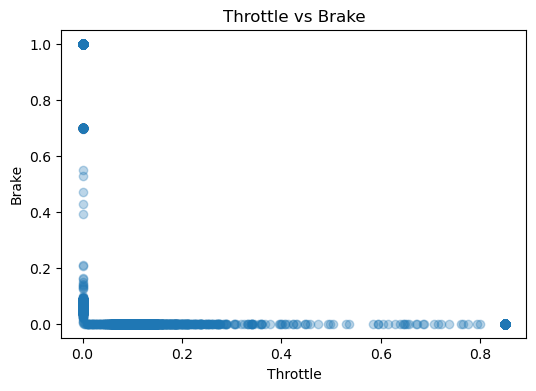

In [19]:
# Throttle vs Brake

plt.figure(figsize=(6,4))
plt.scatter(df_train["throttle"], df_train["brake"], alpha=0.3)
plt.xlabel("Throttle")
plt.ylabel("Brake")
plt.title("Throttle vs Brake")
plt.show()